<a href="https://colab.research.google.com/github/dhandma/advanced-kubernetes-course/blob/master/1_Building_LLM_AI_Flows.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building LLM AI Flows

In [ ]:
from google.colab import userdata

In [ ]:
GPT_API_KEY = userdata.get("GPT_API_KEY")
GOOGLE_API_KEY = userdata.get("GOOGLE_API_KEY")
HF_TOKEN = userdata.get("HF_TOKEN")

print("GPT_API_KEY loaded:", GPT_API_KEY is not None)
print("GOOGLE_API_KEY loaded:", GOOGLE_API_KEY is not None)
print("HF_TOKEN loaded:", HF_TOKEN is not None)

GPT_API_KEY loaded: True
GOOGLE_API_KEY loaded: True
HF_TOKEN loaded: True


We categorise LLM-based systems by the reasoning and interaction steps they perform.

**Types of LLM systems**

1. **Single-shot (one-pass) systems** \
   One prompt produces one response in a single forward pass. The system is stateless, with no intermediate structure. It is simple but weak at long-horizon or compositional reasoning and offers no error recovery.

2. **Multi-step chaining (pipeline-style) systems** \
   Tasks are manually decomposed into sequential LLM calls, where each step feeds into the next. Control flow is deterministic and errors can be isolated per stage. Common in document processing and structured extraction, but the design is rigid and lacks dynamic replanning.

3. **Few-shot / in-context learning systems** \
   Examples are embedded in the prompt to induce behaviour. Inference remains single-pass, and learning occurs through context rather than model updates.

4. **Chain-of-Thought (CoT) systems** \
   The model generates intermediate reasoning steps within a single call. Unlike chaining, reasoning does not span multiple LLM calls.

5. **Multi-turn conversational systems** \
   Responses are conditioned on dialogue history, enabling clarification and user interaction. Memory is limited to the context window unless extended explicitly.

6. **Tool-augmented LLM systems** \
   The LLM decides when to invoke external tools (e.g. search, code execution, databases) and integrates results into its reasoning. This improves factual and numerical accuracy.

7. **Retrieval-Augmented Generation (RAG) systems** \
   Relevant documents are retrieved from an external knowledge base and injected into the prompt before generation. This separates knowledge from reasoning and reduces hallucinations.

8. **Agentic (autonomous) LLM systems** \
   The LLM operates in a control loop: planning, acting, observing, and reflecting until a goal is achieved. Suitable for complex, long-horizon tasks.

9. **Multi-agent LLM systems** \
   Multiple specialised LLM roles interact (e.g. planner, critic, executor), enabling division of labour, debate, and deeper reasoning.


Installing required libraries

In [ ]:
!pip install -q -U google-genai huggingface_hub python-dotenv openai

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 733.5/733.5 kB 12.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 616.3/616.3 kB 25.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 72.3 MB/s eta 0:00:00


### Client-Server Handshake

To build a GenAI application, your local code must "authorise" with a remote brain (where the model is actually computing). Is it simply not feasible to run the models available today, having billions of parameters on our personal systems.

We either access the services through provider-hosted inference points, or deploy the models locally on private infrastructure.

We treat the API (Application Programming Interface) Key as a **Passport** linking each request to a specific account with the provider. This enables access control as well as usage monitoring, billing, and cost tracking for paid LLM services.

**Why use `.env`?**

In production, hard-coding keys is a critical security failure. You need to store the API keys in a safe `.env` file and **avoid uploading it to any project or version management platform, such as GitHub**. If your API keys are uploaded on a public platform, there is a high chance it might get picked up by a scraper, and you might incur additional costs.

We use `python-dotenv` to keep our secrets in a separate, hidden file.

![image.png](attachment:image.png)

What if you want to run your model on your own servers to ensure data privacy? We use the **HuggingFace Ecosystem**.

[**Hugging Face**](https://huggingface.co/) is an open-source platform and ecosystem for machine learning models, with a strong focus on natural language processing and generative AI. It provides a central hub where researchers and practitioners can share, discover, and reuse pre-trained models, datasets, and evaluation tools.

Through libraries such as *Transformers* and *Datasets*, Hugging Face enables developers to load, fine-tune, and deploy models with minimal boilerplate, either locally or via hosted inference APIs. In practice, it acts as an infrastructure layer that lowers the barrier to experimenting with and deploying modern AI models.

> We will use the `InferenceClient` to talk to HF models. This allows us to use an Open Source "Brain" with the same simplicity as a Cloud API.
---

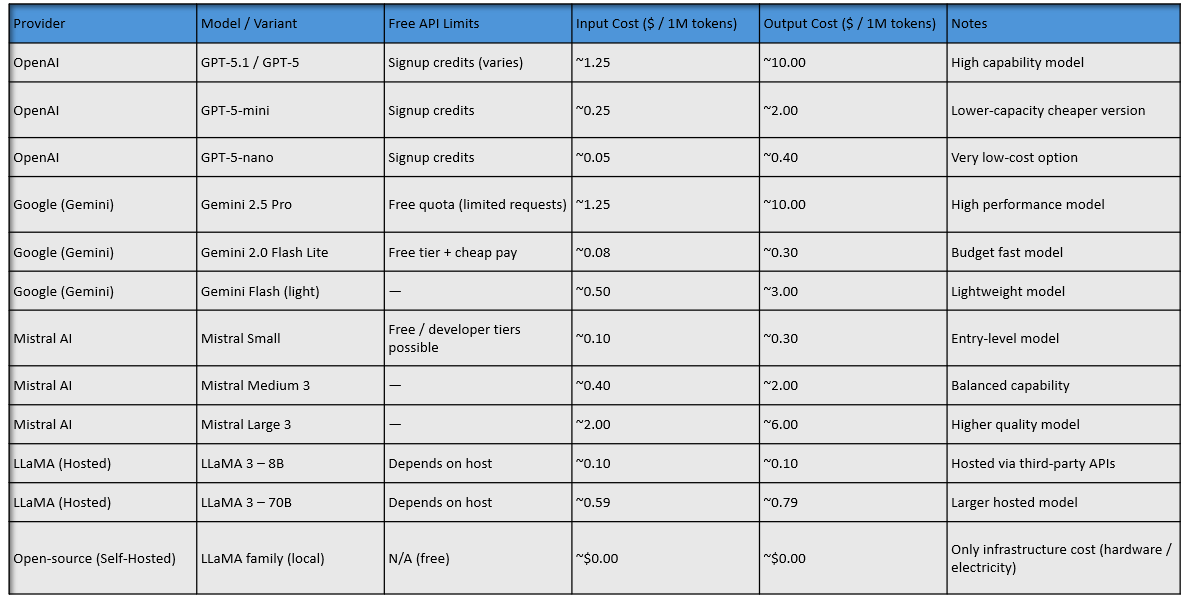

In [ ]:
'''import os
from dotenv import load_dotenv

load_dotenv(override=True)

GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")
HF_TOKEN = os.getenv("HF_TOKEN")

if GOOGLE_API_KEY and HF_TOKEN:
    print("Check: Keys Loaded successfully.")
else:
    print("Check: Keys Missing! Check your `.env` file.")'''

'import os\nfrom dotenv import load_dotenv\n\nload_dotenv(override=True)\n\nGOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")\nHF_TOKEN = os.getenv("HF_TOKEN")\n\nif GOOGLE_API_KEY and HF_TOKEN:\n    print("Check: Keys Loaded successfully.")\nelse:\n    print("Check: Keys Missing! Check your `.env` file.")'

In [ ]:
import json
from google import genai
from huggingface_hub import InferenceClient

## 1. Single-Shot Systems




### 1. Cloud APIs
The most common way to interact with an LLM is through an API provided by a cloud vendor (such as OpenAI, Google, or Anthropic). This is often referred to as "Inference-as-a-Service."

In this architecture, the developer initialises a client object, sends a text payload, and receives a generated response. The function below demonstrates a standard wrapper for a cloud API call.

In [ ]:
# Initialise the Cloud Client
gemini_client = genai.Client(api_key=GOOGLE_API_KEY)

# Let's define a function to send the prompt to the LLM and fetch the response

def get_cloud_completion(prompt, model_id="gemini-2.5-flash"):      # Arguments: prompt and model
    """
    Sends a prompt to the Google Gemini API and returns the text response.
    """

    # Google Gemini uses the method <client.models.generate_content> to generate responses
    # This method varies across different providers

    response = gemini_client.models.generate_content(
                                                    model=model_id,
                                                    contents=prompt)
    return response

In [ ]:
# Example Usage
simple_query = "Explain the concept of 'latency' in software engineering in one sentence."
response = get_cloud_completion(simple_query)
response

GenerateContentResponse(
  automatic_function_calling_history=[],
  candidates=[
    Candidate(
      content=Content(
        parts=[
          Part(
            text='Latency is the duration of time from the initiation of a request or operation to the receipt of its response or completion within a software system.'
          ),
        ],
        role='model'
      ),
      finish_reason=<FinishReason.STOP: 'STOP'>,
      index=0
    ),
  ],
  model_version='gemini-2.5-flash',
  response_id='DSG1aYzDDYPwqtsPgMW-0QM',
  sdk_http_response=HttpResponse(
    headers=<dict len=10>
  ),
  usage_metadata=GenerateContentResponseUsageMetadata(
    candidates_token_count=27,
    prompt_token_count=15,
    prompt_tokens_details=[
      ModalityTokenCount(
        modality=<MediaModality.TEXT: 'TEXT'>,
        token_count=15
      ),
    ],
    thoughts_token_count=1336,
    total_token_count=1378
  )
)

Here, you can see that the response output doesn't only contain the desired response. It is a dictionary style object which also contains other metadata. We can simply extract the text response as follows.

In [ ]:
response.text

'Latency is the duration of time from the initiation of a request or operation to the receipt of its response or completion within a software system.'

### 2. Open Source Pipelines (HuggingFace)

While cloud APIs offer convenience, many enterprise use cases require open-source models for data privacy, control, or cost optimization. Meta's **Llama** is a prominent example of this category.

We can access these models via the **HuggingFace Inference API**, which allows us to treat open-source weights similar to a cloud endpoint.

Note that open-source HF [models](https://huggingface.co/?activityType=update-model&feedType=following) often utilise a specific chat template (`system`/`user` roles) rather than a raw string prompt.

In [ ]:
# Initialise the Hugging Face Client
hf_client = InferenceClient(token=HF_TOKEN)

HF_MODEL = "meta-llama/Meta-Llama-3-8B-Instruct"        # Select a model from available ones on HuggingFace, you can choose any other model as well

def get_oss_completion(user_input, sys_msg = "You are a helpful technical assistant."):
    """
    Sends a message to Llama 3 via Hugging Face Inference API.
    """

    # Constructing the message payload
    messages = [
        {"role": "system", "content": sys_msg},        # Think of this as a system configuration prompt
        {"role": "user", "content": user_input}        # This is the placeholder for user's prompt or query
    ]


    # HF uses the <clinet.chat_completion> method
    response = hf_client.chat_completion(
                                        model=HF_MODEL,
                                        messages=messages,)

    return response

As you saw, for some providers, we can also give system level prompts. For example, ChatGPT is just a product made with the help of GPT family of LLMs. It is the system prompt that makes ChatGPT much more user-friendly than the backend model (GPT). The system prompt tunes how ChatGPT frames its responses.

In [ ]:
# Let's send a query and get response
response = get_oss_completion(simple_query)
response

ChatCompletionOutput(choices=[ChatCompletionOutputComplete(finish_reason='stop', index=0, message=ChatCompletionOutputMessage(role='assistant', content="In software engineering, latency refers to the delay or time it takes for a system or application to respond to a user's input or request, typically measured in milliseconds (ms) and affecting the overall performance and user experience.", reasoning=None, tool_call_id=None, tool_calls=None), logprobs=None, content_filter_results={'hate': {'filtered': False}, 'self_harm': {'filtered': False}, 'sexual': {'filtered': False}, 'violence': {'filtered': False}, 'jailbreak': {'filtered': False, 'detected': False}, 'profanity': {'filtered': False, 'detected': False}})], created=1773478185, id='2004a5c521804cd7a73b2e7c8abc07eb', model='meta-llama/llama-3-8b-instruct', system_fingerprint='', usage=ChatCompletionOutputUsage(completion_tokens=45, prompt_tokens=58, total_tokens=103, prompt_tokens_details=None, completion_tokens_details=None), object

Again, let's extract the required content from the response

In [ ]:
response.choices[0].message.content

"In software engineering, latency refers to the delay or time it takes for a system or application to respond to a user's input or request, typically measured in milliseconds (ms) and affecting the overall performance and user experience."

## 2. Few-Shot/Context-Augmented Systems

A fundamental limitation of LLMs is that their knowledge is restricted to their training data. They do not know about private data, current inventory levels, or specific company policies.

**Context Injection** is the practice of explicitly providing this information within the prompt (the Context Window). This forces the model to answer based on the provided text rather than its general training.

In the example below, we provide a mock "Store Policy" to ensure the model answers a return request correctly.

In [ ]:
# The external knowledge source (Context)
STORE_POLICY = """
RETURN POLICY:
1. Items can be returned within 30 days of purchase.
2. Electronics have a 15% restocking fee if opened.
3. Software subscriptions are non-refundable.
"""

def answer_with_context(user_query):

    # Constructing the system prompt with context
    system_instruction = f"""
        You are a support bot. Answer the user query using ONLY the policy below.

        ### POLICY DATA
        {STORE_POLICY}
        ###
    """

    # For Gemini
    full_prompt = f"{system_instruction}\nUser Query: {user_query}"

    return get_cloud_completion(full_prompt), get_oss_completion(user_query, system_instruction)

In [ ]:
# Example Usage
# Without context, the model might say "Returns are free."
# With context, it should mention the restocking fee.

query = "I opened the box for my laptop but want to return it. Is it free?"

response1, response2 = answer_with_context(query)

In [ ]:
# Check response from both models
response1.text, response2.choices[0].message.content

('Electronics have a 15% restocking fee if opened.',
 'According to our return policy, since you opened the box for your laptop, it falls under the category of electronics. Unfortunately, this means you will incur a 15% restocking fee to facilitate the return.')

Just like we gave some context in the system instructions, we can also give some few-shot examples to help the model understand the task better.

In [ ]:
sys_msg = "You are a helpful assistant"
user_query = "You have to convert a word into a codified numeric string. For example, ABC will become 123; XYZ will become 242526. What will TUV be in this case?"

print(get_oss_completion(user_query, sys_msg).choices[0].message.content)

To convert a word into a codified numeric string, we can use the position of each letter in the alphabet to determine the corresponding number. 

Here's the conversion for the word TUV:

- T is the 20th letter of the alphabet, so it becomes 20.
- U is the 21st letter of the alphabet, so it becomes 21.
- V is the 22nd letter of the alphabet, so it becomes 22.

So, the codified numeric string for TUV is 202122.


## 3. Multi-Step Chaining

Single prompts often fail when a task requires multiple distinct types of reasoning (e.g., "Analyse this, then Write that"). To solve this, we use **Chaining**.

Chaining breaks a complex task into atomic steps. This increases reliability because each model call focuses on a single objective.

**Scenario: Customer Email Processing**

We will build a simple chain with two steps:
1.  **Intent Classifier:** Identify if the email is a `REFUND`, `COMPLAINT`, or `INQUIRY`.
2.  **Response Drafter:** Write a response based specifically on that intent category.

In [ ]:
def identify_intent(email_text):

    """Step 1: Analyzes the email to determine the category."""

    prompt = f"""
    Analyze the following email and categorize it into exactly one of these classes:
    [REFUND, COMPLAINT, PRODUCT_INQUIRY, OTHER]

    Return ONLY the category name.

    Email: "{email_text}"
    """

    # We use the Cloud model for reasoning
    category = get_cloud_completion(prompt)
    return category.text

In [ ]:
def draft_response(email_text, intent):

    """Step 2: Drafts a reply based on the identified intent."""

    prompt = f"""
    You are a customer support agent.
    Incoming Email: "{email_text}"
    Detected Intent: {intent}

    Task: Write a polite, 2-sentence response addressing this specific intent.
    """

    # We use the Open Source model for drafting
    response = get_oss_completion(prompt)
    return response

In [ ]:
def process_email_chain(email_text):
    """The Orchestrator Function linking Step 1 and Step 2."""

    # Execution Step 1
    intent = identify_intent(email_text)
    print(f"DEBUG: Detected Intent -> {intent}")

    # Execution Step 2
    final_response = draft_response(email_text, intent)
    return final_response.choices[0].message.content

In [ ]:
# Example Usage
customer_email = "I ordered the headset last week and it still hasn't arrived. I want my money back."
print("\nFinal Output:")
print(process_email_chain(customer_email))


Final Output:
DEBUG: Detected Intent -> REFUND
"Dear valued customer, 

We apologize for the delay in receiving your order and appreciate your patience as we look into the matter further. To assist you with your refund request, please respond with your order number so we can expedite the process and provide a full refund as per our return policy."


## 4. Chain-of-Thought (CoT) systems

The model is prompted to produce intermediate reasoning steps before arriving at a final answer, all within a single forward pass.

In this setup, reasoning is internal to one model call rather than being distributed across multiple calls, as in multi-step chaining. By encouraging the model to “think step by step”, performance improves on tasks that require logical decomposition, arithmetic reasoning, or structured decision-making.


**Limitations**
- Reasoning is not modular or inspectable at the system level
- No error recovery or replanning
- Less controllable than multi-step pipelines


In [ ]:
# Single-shot inference without Chain-of-Thought

prompt = """
A company offers two subscription plans:

Plan A: ₹300 per month + ₹2 per API call
Plan B: ₹500 per month + ₹1 per API call

For what minimum number of API calls does Plan B become cheaper than Plan A?

Give only the final answer.
"""

response = get_oss_completion(prompt)

print(response.choices[0].message.content)

15000 API calls.


In [ ]:
# Single-shot inference with Chain-of-Thought

prompt = """
A company offers two subscription plans:

Plan A: ₹300 per month + ₹2 per API call
Plan B: ₹500 per month + ₹1 per API call

Determine the minimum number of API calls for which Plan B becomes cheaper than Plan A.

First, write out the cost equations for both plans.
Then solve the inequality step by step.
Finally, state the minimum number of API calls.
"""

response = get_oss_completion(prompt)

print(response.choices[0].message.content)

**Cost Equations for Both Plans:**

Let's denote the cost of Plan A as CA and the cost of Plan B as CB. 

Plan A: CA = 300 + 2n
Plan B: CB = 500 + 1n

where n is the number of API calls.

**Solving the Inequality:**

Plan B becomes cheaper than Plan A when CB < CA. 

To find the minimum number of API calls for which Plan B is cheaper, we need to solve the inequality:

500 + n < 300 + 2n

Now, let's simplify the inequality:

500 - 300 < 2n - n
200 < n

So, the inequality is satisfied when n > 200. This means that Plan B becomes cheaper than Plan A when the number of API calls is greater than 200.

Therefore, the **minimum number of API calls** for which Plan B is cheaper than Plan A is 201.
